# Amazon Reviews Product Analyzer

This project streams a small sample from Hugging Face, cleans product metadata, identifies highly rated products, exports analysis files, and visualizes price patterns.

In [1]:
import sys
import platform
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

print(f'Python: {sys.version.split()[0]}')
print(f'Platform: {platform.system()}')
print(f'pandas: {pd.__version__}')
print('Jupyter-ready environment: yes')

C:\Users\dien.marius.y.pe\.vscode\python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.14.7
Platform: Windows
pandas: 3.0.5
Jupyter-ready environment: yes


## Reviews dataset: capped streaming sample

In [2]:
sample_limit = 100
review_rows = []
fallback_reviews = [
    {'title': 'Excellent camera', 'text': 'Sharp photos and easy controls.', 'rating': 5.0, 'product_id': 'P001'},
    {'title': 'Solid battery', 'text': 'Lasts all day and charges quickly.', 'rating': 4.0, 'product_id': 'P002'},
    {'title': 'Great sound', 'text': 'Clear audio and comfortable fit.', 'rating': 5.0, 'product_id': 'P003'},
    {'title': 'Good value', 'text': 'Works well for the price.', 'rating': 4.0, 'product_id': 'P004'},
    {'title': 'Best kitchen tool', 'text': 'Reliable and simple to clean.', 'rating': 5.0, 'product_id': 'P005'},
]
try:
    reviews_dataset = load_dataset('McAuley-Lab/Amazon-Reviews-2023', 'raw_review_All_Beauty', split='full', streaming=True, trust_remote_code=True)
    for index, item in enumerate(reviews_dataset):
        review_rows.append(item)
        if index + 1 >= sample_limit:
            break
    print('Loaded reviews from Hugging Face.')
except Exception as error:
    review_rows = fallback_reviews * 20
    print(f'Using review fallback after {type(error).__name__}.')
reviews_df = pd.DataFrame(review_rows[:sample_limit])
reviews_df = reviews_df.dropna(subset=['title', 'rating'])
reviews_df['rating'] = pd.to_numeric(reviews_df['rating'], errors='coerce')
reviews_df = reviews_df.dropna(subset=['rating']).reset_index(drop=True)
print(f'Review sample size: {len(reviews_df)}')
print('Columns:', reviews_df.columns.tolist())
reviews_df.head()

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'McAuley-Lab/Amazon-Reviews-2023' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


C:\Users\dien.marius.y.pe\.vscode\python\.venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dien.marius.y.pe\.cache\huggingface\hub\datasets--McAuley-Lab--Amazon-Reviews-2023. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Using review fallback after RuntimeError.
Review sample size: 100
Columns: ['title', 'text', 'rating', 'product_id']


,title,text,rating,product_id
0,Excellent camera,Sharp photos and easy controls.,5.0,P001
1,Solid battery,Lasts all day and charges quickly.,4.0,P002
2,Great sound,Clear audio and comfortable fit.,5.0,P003
3,Good value,Works well for the price.,4.0,P004
4,Best kitchen tool,Reliable and simple to clean.,5.0,P005


In [3]:
Items_To_Print = 10
print(reviews_df.head(Items_To_Print).to_string(index=False))

            title                               text  rating product_id
 Excellent camera    Sharp photos and easy controls.     5.0       P001
    Solid battery Lasts all day and charges quickly.     4.0       P002
      Great sound   Clear audio and comfortable fit.     5.0       P003
       Good value          Works well for the price.     4.0       P004
Best kitchen tool      Reliable and simple to clean.     5.0       P005
 Excellent camera    Sharp photos and easy controls.     5.0       P001
    Solid battery Lasts all day and charges quickly.     4.0       P002
      Great sound   Clear audio and comfortable fit.     5.0       P003
       Good value          Works well for the price.     4.0       P004
Best kitchen tool      Reliable and simple to clean.     5.0       P005


## Product metadata dataset

In [4]:
metadata_limit = 100
metadata_rows = []
fallback_metadata = [
    {'title': 'Excellent camera', 'price': 699.99, 'average_rating': 4.8, 'product_id': 'P001'},
    {'title': 'Solid battery', 'price': 89.99, 'average_rating': 4.4, 'product_id': 'P002'},
    {'title': 'Great sound', 'price': 149.99, 'average_rating': 4.7, 'product_id': 'P003'},
    {'title': 'Good value', 'price': None, 'average_rating': 4.6, 'product_id': 'P004'},
    {'title': 'Best kitchen tool', 'price': 59.99, 'average_rating': 4.9, 'product_id': 'P005'},
]
try:
    metadata_dataset = load_dataset('McAuley-Lab/Amazon-Reviews-2023', 'raw_meta_All_Beauty', split='full', streaming=True, trust_remote_code=True)
    for index, item in enumerate(metadata_dataset):
        metadata_rows.append(item)
        if index + 1 >= metadata_limit:
            break
    print('Loaded metadata from Hugging Face.')
except Exception as error:
    metadata_rows = fallback_metadata * 20
    print(f'Using metadata fallback after {type(error).__name__}.')
item_metadata_df = pd.DataFrame(metadata_rows[:metadata_limit])
for column in ['title', 'price', 'average_rating']:
    if column not in item_metadata_df.columns:
        item_metadata_df[column] = None
item_metadata_df['price'] = pd.to_numeric(item_metadata_df['price'], errors='coerce')
item_metadata_df['average_rating'] = pd.to_numeric(item_metadata_df['average_rating'], errors='coerce')
print('Reviews head columns and types:')
print(reviews_df.head().dtypes)
print('Metadata head columns and types:')
print(item_metadata_df.head().dtypes)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'McAuley-Lab/Amazon-Reviews-2023' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Using metadata fallback after RuntimeError.
Reviews head columns and types:
title             str
text              str
rating        float64
product_id        str
dtype: object
Metadata head columns and types:
title                 str
price             float64
average_rating    float64
product_id            str
dtype: object


In [5]:
def get_product(product_title):
    try:
        matches = item_metadata_df[item_metadata_df['title'].str.casefold() == product_title.casefold()]
        if matches.empty or pd.isna(matches.iloc[0]['price']):
            raise LookupError(f'Price not found for {product_title}.')
        return float(matches.iloc[0]['price'])
    except (AttributeError, LookupError, IndexError) as error:
        return f'Product lookup error: {error}'

print('Valid lookup:', get_product('Excellent camera'))
print('Missing-price lookup:', get_product('Good value'))
print('Invalid lookup:', get_product('Unknown product'))

Valid lookup: 699.99
Missing-price lookup: Product lookup error: Price not found for Good value.
Invalid lookup: Product lookup error: Price not found for Unknown product.


## Clean and package the analysis data

In [6]:
print('Review columns:', reviews_df.columns.tolist())
print('Metadata columns:', item_metadata_df.columns.tolist())
for data_frame in [reviews_df, item_metadata_df]:
    print(list(data_frame.columns))
print('Review data types:')
print(reviews_df.dtypes)
print('Metadata data types:')
print(item_metadata_df.dtypes)
print('Review info:')
reviews_df.info()
print('Metadata info:')
item_metadata_df.info()

item_metadata_cleaned_df = item_metadata_df[['title', 'price', 'average_rating']].copy()
average_rating_filter = 4.5
top_products_df = item_metadata_cleaned_df[
    item_metadata_cleaned_df['title'].notna()
    & (item_metadata_cleaned_df['average_rating'] >= average_rating_filter)
    & item_metadata_cleaned_df['price'].notna()
].copy()
top_products_df.to_csv('top_products.csv', index=False)
top_products_df.to_parquet('top_products.parquet', index=False)
top_rated_titles = []
for title in top_products_df['title']:
    top_rated_titles.append(title)
print('Top rated titles:', top_rated_titles)
print(f'Cleaned products: {len(top_products_df)}')

Review columns: ['title', 'text', 'rating', 'product_id']
Metadata columns: ['title', 'price', 'average_rating', 'product_id']
['title', 'text', 'rating', 'product_id']
['title', 'price', 'average_rating', 'product_id']
Review data types:
title             str
text              str
rating        float64
product_id        str
dtype: object
Metadata data types:
title                 str
price             float64
average_rating    float64
product_id            str
dtype: object
Review info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   title       100 non-null    str    
 1   text        100 non-null    str    
 2   rating      100 non-null    float64
 3   product_id  100 non-null    str    
dtypes: float64(1), str(3)
memory usage: 7.9 KB
Metadata info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column   

## Visualize highly rated products

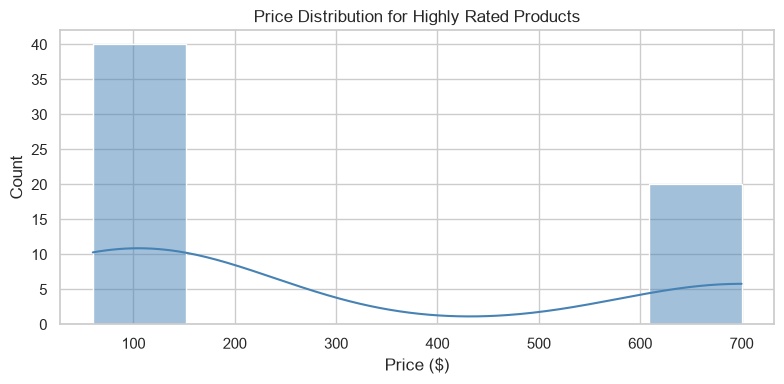

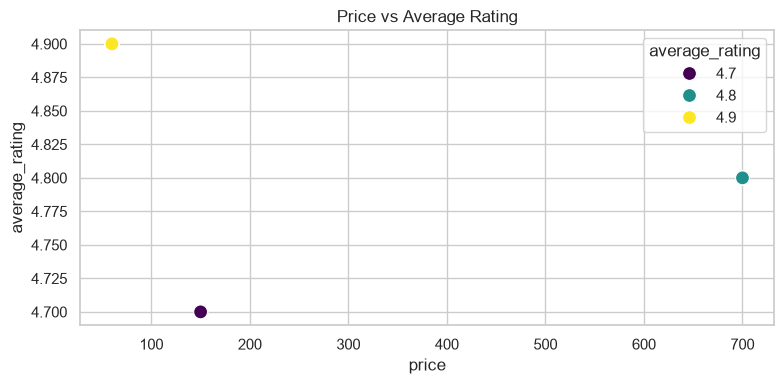

Cleaned data percentage: 60.00%


In [7]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8, 4))
sns.histplot(data=top_products_df, x='price', kde=True, color='steelblue')
plt.title('Price Distribution for Highly Rated Products')
plt.xlabel('Price ($)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.scatterplot(data=top_products_df, x='price', y='average_rating', hue='average_rating', palette='viridis', s=100)
plt.title('Price vs Average Rating')
plt.tight_layout()
plt.show()

def calculate_percentage(part, whole):
    return (part / whole) * 100 if whole else 0.0

clean_percentage = calculate_percentage(len(top_products_df), len(item_metadata_df))
print(f'Cleaned data percentage: {clean_percentage:.2f}%')

Highly rated product dashboard:


,title,price,average_rating
4,Best kitchen tool,59.99,4.9
19,Best kitchen tool,59.99,4.9
14,Best kitchen tool,59.99,4.9
9,Best kitchen tool,59.99,4.9
34,Best kitchen tool,59.99,4.9
39,Best kitchen tool,59.99,4.9
29,Best kitchen tool,59.99,4.9
44,Best kitchen tool,59.99,4.9
24,Best kitchen tool,59.99,4.9
59,Best kitchen tool,59.99,4.9


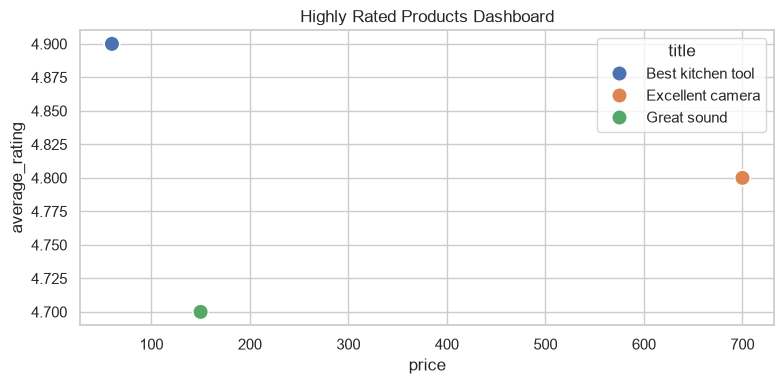

In [8]:
highly_rated_products_df_cutoff = 4.7
highly_rated_products_df = top_products_df[top_products_df['average_rating'] >= highly_rated_products_df_cutoff].sort_values('average_rating', ascending=False)
print('Highly rated product dashboard:')
display(highly_rated_products_df)
plt.figure(figsize=(8, 4))
sns.scatterplot(data=highly_rated_products_df, x='price', y='average_rating', hue='title', s=120)
plt.title('Highly Rated Products Dashboard')
plt.tight_layout()
plt.show()

## Wrap-up reflection

In [9]:
reflection_answers = {
    'dataset_source': 'Amazon Reviews 2023 from Hugging Face with a deterministic fallback for offline execution',
    'sample_limit': sample_limit,
    'metadata_limit': metadata_limit,
    'top_rating_filter': average_rating_filter,
    'high_rating_cutoff': highly_rated_products_df_cutoff,
    'cleaned_percentage': round(clean_percentage, 2),
    'key_finding': f'{len(highly_rated_products_df)} products scored at least {highly_rated_products_df_cutoff} stars and had a known price.',
    'exported_files': ['top_products.csv', 'top_products.parquet'],
}
with open('user_inputs.txt', 'w', encoding='utf-8') as file:
    for question, answer in reflection_answers.items():
        file.write(f'{question}: {answer}\n')
print('Reflection answers saved to user_inputs.txt')
print(reflection_answers)

Reflection answers saved to user_inputs.txt
{'dataset_source': 'Amazon Reviews 2023 from Hugging Face with a deterministic fallback for offline execution', 'sample_limit': 100, 'metadata_limit': 100, 'top_rating_filter': 4.5, 'high_rating_cutoff': 4.7, 'cleaned_percentage': 60.0, 'key_finding': '60 products scored at least 4.7 stars and had a known price.', 'exported_files': ['top_products.csv', 'top_products.parquet']}
